<a href="https://colab.research.google.com/github/lce2005/2026DeepLearningClass_Assignment_1/blob/main/deeplearning_a1_1ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch #딥러닝에 사용되는 파이토치 라이브러리
import torch.nn as nn #신경망을 만드는 기능

from torchvision.models import resnet18, ResNet18_Weights

# GPU를 사용할 수 있으면 GPU, 아니면 CPU를 선택
device = torch.device(
    "cuda" if torch.cuda.is_available() else "gpu"
)

print("사용 장치:", device)

if device.type == "cuda":
    print("GPU 이름:", torch.cuda.get_device_name(0))


사용 장치: cuda
GPU 이름: Tesla T4


In [ ]:
# ImageNet으로 미리 학습된 가중치 선택
weights = ResNet18_Weights.DEFAULT

# 사전학습된 ResNet18 모델 불러오기
model = resnet18(weights=weights)

print("ResNet18 불러오기 완료")
print("기존 마지막 분류층:", model.fc)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


ResNet18 불러오기 완료
기존 마지막 분류층: Linear(in_features=512, out_features=1000, bias=True)


In [ ]:
# 기존 분류층에 들어가는 특징의 개수 확인
num_features = model.fc.in_features

# 마지막 분류층을 512 → 10으로 교체
model.fc = nn.Linear(num_features, 10)

# 모델을 GPU로 이동
model = model.to(device)

print("교체한 마지막 분류층:", model.fc)
print("모델이 올라간 장치:", next(model.parameters()).device)


교체한 마지막 분류층: Linear(in_features=512, out_features=10, bias=True)
모델이 올라간 장치: cuda:0


In [ ]:
# 동작 확인용 가짜 이미지 4장
# 모양: [이미지 수, 색상 채널 수, 높이, 너비]
dummy_images = torch.randn(4, 3, 64, 64).to(device)

# 평가 모드: 이번 동작 확인 중 내부 통계가 바뀌지 않도록 함
model.eval()

# 학습 없이 출력만 계산
with torch.no_grad():
    outputs = model(dummy_images)

print("입력 모양:", dummy_images.shape)
print("출력 모양:", outputs.shape)


입력 모양: torch.Size([4, 3, 64, 64])
출력 모양: torch.Size([4, 10])


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 사전학습된 ResNet18에 맞춰 사용할 정규화 값
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

# 이미지를 모델 입력으로 변환하는 순서
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

print("이미지 전처리 설정 완료")


이미지 전처리 설정 완료


In [ ]:
# 학습에 사용할 이미지 50,000장
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

# 최종 평가에 사용할 이미지 10,000장
test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

# 클래스 이름: 라벨 번호 0~9에 해당
class_names = train_dataset.classes

print("훈련 이미지 수:", len(train_dataset))
print("테스트 이미지 수:", len(test_dataset))
print("클래스 이름:", class_names)


100%|██████████| 170M/170M [21:30<00:00, 132kB/s] 


훈련 이미지 수: 50000
테스트 이미지 수: 10000
클래스 이름: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
)

print("훈련 배치 수:", len(train_loader))
print("테스트 배치 수:", len(test_loader))


훈련 배치 수: 391
테스트 배치 수: 79


In [ ]:
# 훈련 데이터에서 한 배치 꺼내기
images, labels = next(iter(train_loader))

print("이미지 묶음 모양:", images.shape)
print("정답 묶음 모양:", labels.shape)

print("앞의 8개 정답 번호:", labels[:8].tolist())
print(
    "앞의 8개 정답 이름:",
    [class_names[label] for label in labels[:8].tolist()]
)


이미지 묶음 모양: torch.Size([128, 3, 64, 64])
정답 묶음 모양: torch.Size([128])
앞의 8개 정답 번호: [5, 4, 6, 1, 8, 7, 2, 0]
앞의 8개 정답 이름: ['dog', 'deer', 'frog', 'automobile', 'ship', 'horse', 'bird', 'airplane']


In [ ]:
# 이미지를 모델과 같은 장치(GPU)로 이동
images = images.to(device)

# 학습 없이 동작만 확인
model.eval()

with torch.no_grad():
    outputs = model(images)

print("실제 이미지 입력 모양:", images.shape)
print("모델 출력 모양:", outputs.shape)


실제 이미지 입력 모양: torch.Size([128, 3, 64, 64])
모델 출력 모양: torch.Size([128, 10])


In [ ]:
!pip -q install koreanize-matplotlib

import os
import json
import random
import copy

import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, TensorDataset
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive

# 드라이브 연결: 실행 중 계정 연결 안내가 나오면 승인
drive.mount("/content/drive")

SAVE_DIR = Path("/content/drive/MyDrive/Assignment1_TwoNeurons")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 이후 실행의 무작위성 제어
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 처음 만든 분류층은 시드 설정 이전에 생성되었을 수 있으므로,
# 지금 시드로 다시 초기화하고 여기부터 본 실험을 시작
model.fc.reset_parameters()

COLORS = [
    "#1751D0", "#E2661E", "#0E9E8F", "#C08A00",
    "#D95D8F", "#2E7D32", "#9117D0", "#C1232C"
]

LOSS_CMAP = LinearSegmentedColormap.from_list(
    "loss_blue",
    ["#E8EEFB", "#C2D3F4", "#8FAEEA",
     "#4E7FDD", "#1751D0", "#1241A6", "#0D317D"]
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# 나중에 그림과 설명을 모아 저장
figures = {}
captions = {}

print("저장 위치:", SAVE_DIR)
print("사용 장치:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 83.6 MB/s eta 0:00:00
Mounted at /content/drive
저장 위치: /content/drive/MyDrive/Assignment1_TwoNeurons
사용 장치: cuda


In [ ]:
# 백본을 포함한 모든 파라미터 학습 허용
for param in model.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

# 백본 미세조정용 학습률:
# 과제에 고정값이 지정되어 있지 않아 1e-4를 선택
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

BACKBONE_EPOCHS = 3
backbone_history = []

for epoch in range(BACKBONE_EPOCHS):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    progress = tqdm(
        train_loader,
        desc=f"백본 학습 {epoch + 1}/{BACKBONE_EPOCHS}"
    )

    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # 이전 배치의 그래디언트 초기화
        optimizer.zero_grad(set_to_none=True)

        # 예측
        logits = model(images)

        # 손실 계산
        loss = criterion(logits, labels)

        # 그래디언트 계산
        loss.backward()

        # 가중치 수정
        optimizer.step()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (
            logits.argmax(dim=1) == labels
        ).sum().item()
        total_count += batch_size

        progress.set_postfix(
            loss=f"{total_loss / total_count:.4f}",
            accuracy=f"{100 * total_correct / total_count:.2f}%"
        )

    epoch_loss = total_loss / total_count
    epoch_acc = 100 * total_correct / total_count

    backbone_history.append({
        "epoch": epoch + 1,
        "train_loss": epoch_loss,
        "train_accuracy": epoch_acc
    })

    # 각 epoch가 끝날 때 드라이브에 저장
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "completed_epochs": epoch + 1,
            "history": backbone_history,
        },
        SAVE_DIR / "resnet18_cifar10_checkpoint.pt"
    )

    print(
        f"[{epoch + 1}/{BACKBONE_EPOCHS}] "
        f"훈련 손실={epoch_loss:.4f}, "
        f"훈련 정확도={epoch_acc:.2f}%"
    )

print("CIFAR-10 백본 미세조정 완료")


백본 학습 1/3:   0%|          | 0/391 [00:00<?, ?it/s]

[1/3] 훈련 손실=0.5644, 훈련 정확도=80.88%


백본 학습 2/3:   0%|          | 0/391 [00:00<?, ?it/s]

[2/3] 훈련 손실=0.1883, 훈련 정확도=93.68%


백본 학습 3/3:   0%|          | 0/391 [00:00<?, ?it/s]

[3/3] 훈련 손실=0.0685, 훈련 정확도=97.87%
CIFAR-10 백본 미세조정 완료


In [ ]:
# 기존 모델을 복사해서 마지막 분류층만 제거
backbone = copy.deepcopy(model)

# Identity는 입력을 그대로 출력하는 층
# 따라서 이제 backbone은 클래스 점수 대신 512차원 특징을 출력
backbone.fc = nn.Identity()

backbone = backbone.to(device)
backbone.eval()

# 백본의 모든 파라미터 고정
for param in backbone.parameters():
    param.requires_grad = False

# 특징 저장 시 데이터 순서를 일정하게 유지
train_feature_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

test_feature_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

@torch.no_grad()
def extract_features(loader, description):
    all_features = []
    all_labels = []

    backbone.eval()

    for images, labels in tqdm(loader, desc=description):
        images = images.to(device, non_blocking=True)

        features = backbone(images)

        all_features.append(features.cpu())
        all_labels.append(labels.cpu())

    return (
        torch.cat(all_features, dim=0),
        torch.cat(all_labels, dim=0)
    )

X_train, y_train = extract_features(
    train_feature_loader,
    "훈련 특징 추출"
)

X_test, y_test = extract_features(
    test_feature_loader,
    "테스트 특징 추출"
)

print("훈련 특징:", X_train.shape)
print("테스트 특징:", X_test.shape)

assert X_train.shape == (50000, 512)
assert X_test.shape == (10000, 512)

# 최종 백본 저장
torch.save(
    backbone.state_dict(),
    SAVE_DIR / "frozen_backbone.pt"
)

print("백본 고정 및 특징 추출 완료")


훈련 특징 추출:   0%|          | 0/196 [00:00<?, ?it/s]

테스트 특징 추출:   0%|          | 0/40 [00:00<?, ?it/s]

훈련 특징: torch.Size([50000, 512])
테스트 특징: torch.Size([10000, 512])
백본 고정 및 특징 추출 완료


In [ ]:
class TwoNeuronHead(nn.Module):
    def __init__(self):
        super().__init__()

        self.bottleneck = nn.Linear(512, 2)
        self.classifier = nn.Linear(2, 10)

    def forward(self, features):
        z = self.bottleneck(features)
        logits = self.classifier(z)
        return logits

    def encode(self, features):
        return self.bottleneck(features)


torch.manual_seed(SEED)

baseline_head = nn.Linear(512, 10).to(device)
two_head = TwoNeuronHead().to(device)

print("기준 헤드:")
print(baseline_head)

print("\n두 뉴런 헤드:")
print(two_head)

print(
    "\n두 뉴런 헤드의 파라미터 수:",
    sum(p.numel() for p in two_head.parameters())
)


기준 헤드:
Linear(in_features=512, out_features=10, bias=True)

두 뉴런 헤드:
TwoNeuronHead(
  (bottleneck): Linear(in_features=512, out_features=2, bias=True)
  (classifier): Linear(in_features=2, out_features=10, bias=True)
)

두 뉴런 헤드의 파라미터 수: 1056


In [ ]:
HEAD_EPOCHS = 40
HEAD_LR = 1e-3
HEAD_BATCH_SIZE = 256

def train_head(head, name):
    # 두 모델에 같은 배치 순서를 제공
    generator = torch.Generator().manual_seed(SEED)

    loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=HEAD_BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0
    )

    optimizer = torch.optim.Adam(
        head.parameters(),
        lr=HEAD_LR
    )

    history = []

    for epoch in tqdm(range(HEAD_EPOCHS), desc=name):
        head.train()

        loss_sum = 0.0
        correct = 0
        count = 0

        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = head(features)
            loss = F.cross_entropy(logits, labels)

            loss.backward()
            optimizer.step()

            n = labels.size(0)

            loss_sum += loss.item() * n
            correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()
            count += n

        row = {
            "epoch": epoch + 1,
            "train_loss": loss_sum / count,
            "train_accuracy": 100 * correct / count
        }

        history.append(row)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"{name} | {epoch + 1}/{HEAD_EPOCHS} | "
                f"손실 {row['train_loss']:.4f} | "
                f"훈련 정확도 {row['train_accuracy']:.2f}%"
            )

    head.eval()
    return history


baseline_history = train_head(
    baseline_head,
    "기준 헤드 학습"
)

torch.save(
    baseline_head.state_dict(),
    SAVE_DIR / "baseline_head.pt"
)

two_history = train_head(
    two_head,
    "두 뉴런 헤드 학습"
)

torch.save(
    two_head.state_dict(),
    SAVE_DIR / "two_neuron_head.pt"
)

print("두 헤드 학습 및 저장 완료")


기준 헤드 학습:   0%|          | 0/40 [00:00<?, ?it/s]

기준 헤드 학습 | 1/40 | 손실 0.1229 | 훈련 정확도 97.11%
기준 헤드 학습 | 10/40 | 손실 0.0056 | 훈련 정확도 99.87%
기준 헤드 학습 | 20/40 | 손실 0.0022 | 훈련 정확도 99.97%
기준 헤드 학습 | 30/40 | 손실 0.0009 | 훈련 정확도 100.00%
기준 헤드 학습 | 40/40 | 손실 0.0004 | 훈련 정확도 100.00%


두 뉴런 헤드 학습:   0%|          | 0/40 [00:00<?, ?it/s]

두 뉴런 헤드 학습 | 1/40 | 손실 1.3190 | 훈련 정확도 51.15%
두 뉴런 헤드 학습 | 10/40 | 손실 0.3317 | 훈련 정확도 89.29%
두 뉴런 헤드 학습 | 20/40 | 손실 0.2792 | 훈련 정확도 91.08%
두 뉴런 헤드 학습 | 30/40 | 손실 0.2612 | 훈련 정확도 91.72%
두 뉴런 헤드 학습 | 40/40 | 손실 0.2499 | 훈련 정확도 92.09%
두 헤드 학습 및 저장 완료


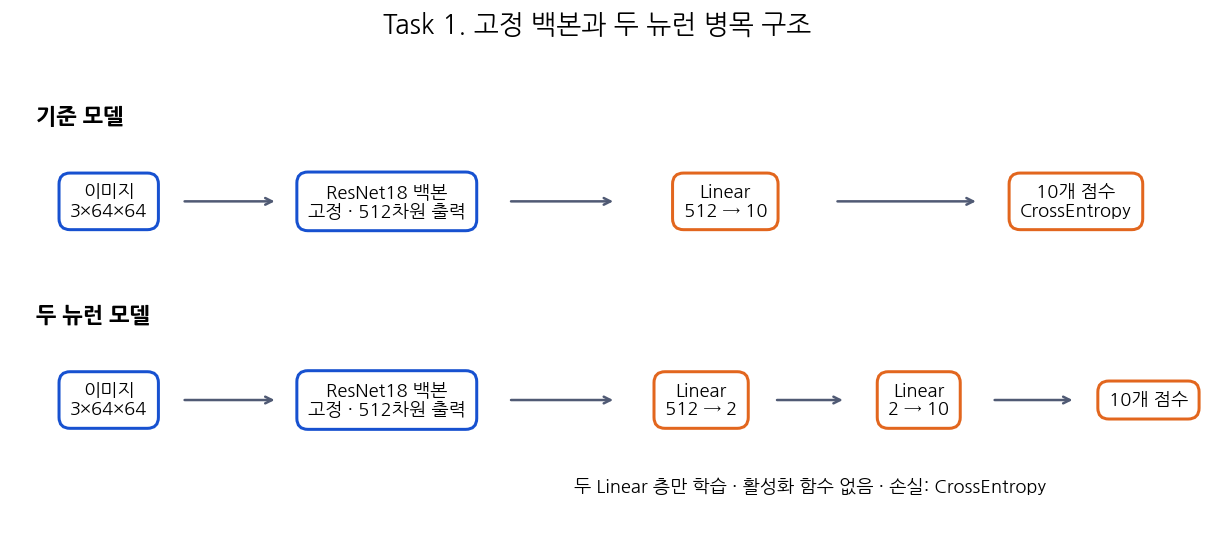

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def box(x, y, text, color):
    ax.text(
        x, y, text,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.6",
            facecolor="white",
            edgecolor=color,
            linewidth=1.8
        )
    )

def arrow(x1, x2, y):
    ax.annotate(
        "",
        xy=(x2, y),
        xytext=(x1, y),
        arrowprops=dict(
            arrowstyle="->",
            color="#505A74",
            linewidth=1.5
        )
    )

ax.text(0.02, 0.89, "기준 모델", fontsize=13, weight="bold")
ax.text(0.02, 0.46, "두 뉴런 모델", fontsize=13, weight="bold")

for y in [0.72, 0.29]:
    box(0.08, y, "이미지\n3×64×64", COLORS[0])
    box(0.31, y, "ResNet18 백본\n고정 · 512차원 출력", COLORS[0])
    arrow(0.14, 0.22, y)
    arrow(0.41, 0.50, y)

box(0.59, 0.72, "Linear\n512 → 10", COLORS[1])
box(0.88, 0.72, "10개 점수\nCrossEntropy", COLORS[1])
arrow(0.68, 0.80, 0.72)

box(0.57, 0.29, "Linear\n512 → 2", COLORS[1])
box(0.75, 0.29, "Linear\n2 → 10", COLORS[1])
box(0.94, 0.29, "10개 점수", COLORS[1])

arrow(0.63, 0.69, 0.29)
arrow(0.81, 0.88, 0.29)

ax.text(
    0.66, 0.09,
    "두 Linear 층만 학습 · 활성화 함수 없음 · 손실: CrossEntropy",
    ha="center", fontsize=11
)

fig.suptitle("Task 1. 고정 백본과 두 뉴런 병목 구조", fontsize=16)

captions["task1"] = (
    "CIFAR-10으로 미세조정한 ResNet18 백본을 고정하고, "
    "기준 헤드 512→10과 두 뉴런 헤드 512→2→10을 각각 학습하였다."
)

figures["task1"] = fig

fig.savefig(
    SAVE_DIR / "task1_architecture.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()


In [ ]:
@torch.no_grad()
def evaluate_head(head):
    loader = DataLoader(
        TensorDataset(X_test, y_test),
        batch_size=512,
        shuffle=False
    )

    head.eval()

    all_predictions = []
    total_loss = 0.0
    count = 0

    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)

        logits = head(features)
        loss = F.cross_entropy(
            logits,
            labels,
            reduction="sum"
        )

        total_loss += loss.item()
        count += labels.size(0)

        all_predictions.append(
            logits.argmax(dim=1).cpu()
        )

    predictions = torch.cat(all_predictions)

    accuracy = (
        (predictions == y_test).float().mean().item() * 100
    )

    return accuracy, total_loss / count, predictions


baseline_acc, baseline_loss, baseline_pred = evaluate_head(
    baseline_head
)

two_acc, two_loss, two_pred = evaluate_head(two_head)

accuracy_drop = baseline_acc - two_acc

print(f"기준 모델 테스트 정확도: {baseline_acc:.2f}%")
print(f"두 뉴런 모델 테스트 정확도: {two_acc:.2f}%")
print(f"정확도 차이(기준 - 두 뉴런): {accuracy_drop:.2f}%p")


기준 모델 테스트 정확도: 89.52%
두 뉴런 모델 테스트 정확도: 79.97%
정확도 차이(기준 - 두 뉴런): 9.55%p


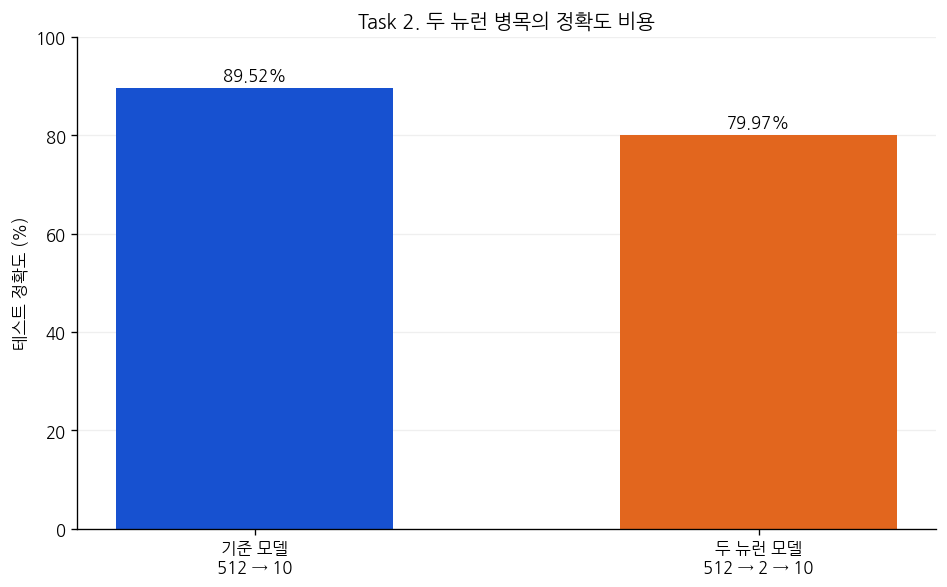

두 뉴런 모델의 테스트 정확도는 79.97%로, 기준 모델의 89.52%보다 9.55%p 낮았다.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

values = [baseline_acc, two_acc]
names = ["기준 모델\n512 → 10", "두 뉴런 모델\n512 → 2 → 10"]

bars = ax.bar(
    names,
    values,
    color=COLORS[:2],
    width=0.55
)

ax.set_ylim(0, 100)
ax.set_ylabel("테스트 정확도 (%)")
ax.set_title("Task 2. 두 뉴런 병목의 정확도 비용")
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

if accuracy_drop >= 0:
    comparison = f"{accuracy_drop:.2f}%p 낮았다"
else:
    comparison = f"{abs(accuracy_drop):.2f}%p 높았다"

captions["task2"] = (
    f"두 뉴런 모델의 테스트 정확도는 {two_acc:.2f}%로, "
    f"기준 모델의 {baseline_acc:.2f}%보다 {comparison}."
)

figures["task2"] = fig

fig.tight_layout()
fig.savefig(
    SAVE_DIR / "task2_accuracy.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()
print(captions["task2"])


2차원 특징 모양: (10000, 2)


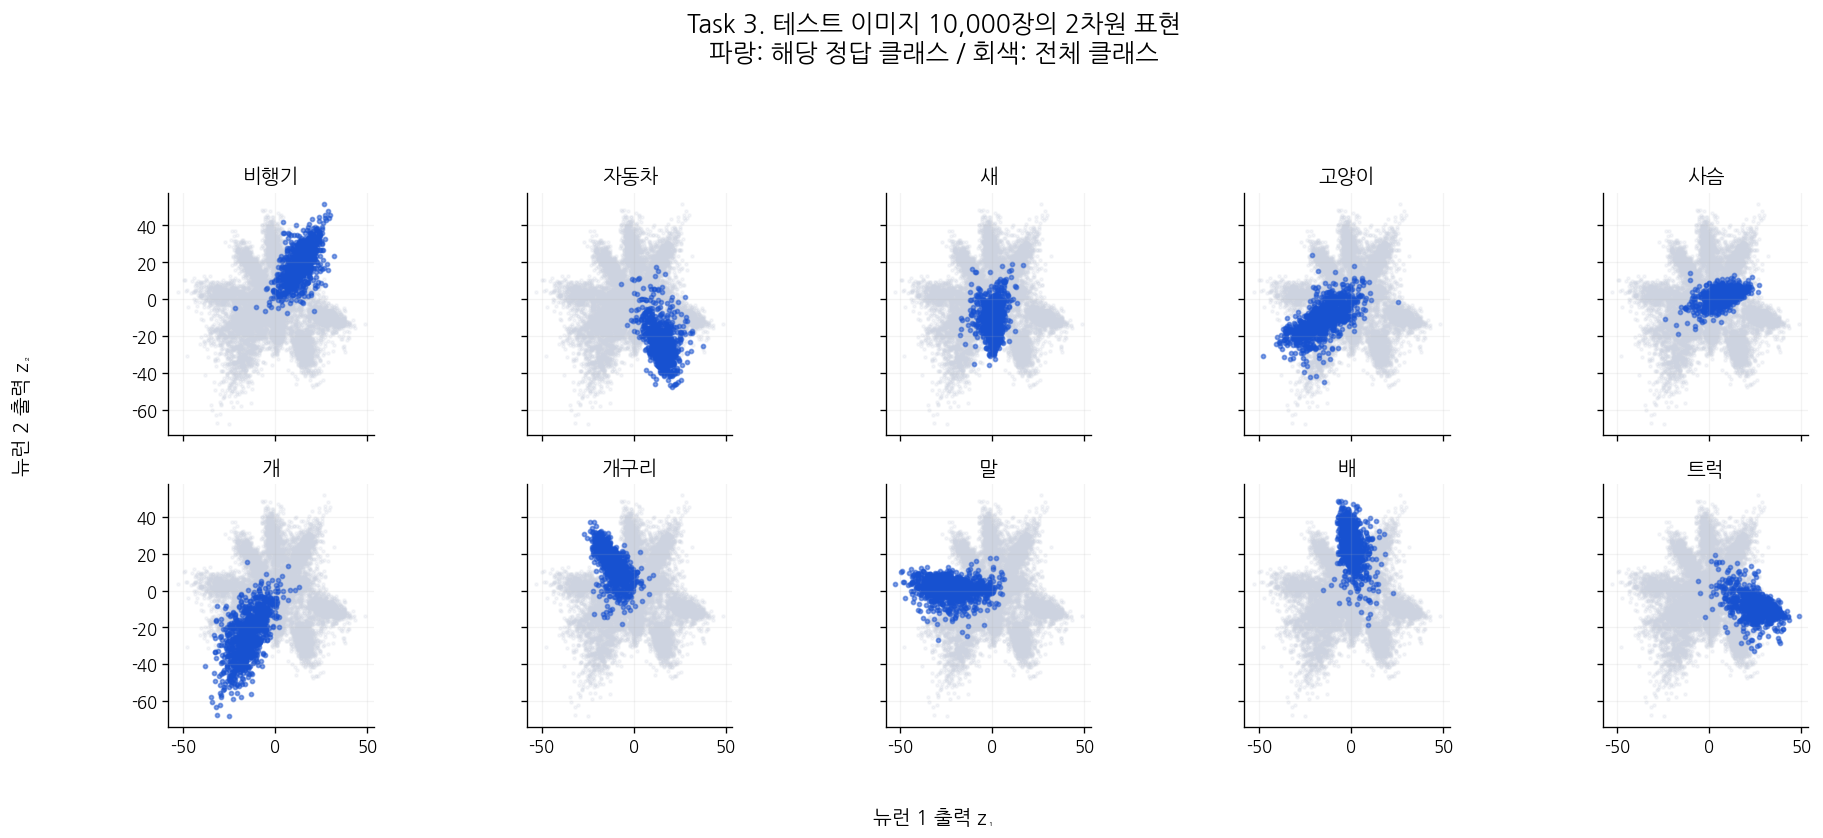

In [ ]:
@torch.no_grad()
def get_2d_features():
    two_head.eval()

    chunks = []

    for features in X_test.split(512):
        z = two_head.encode(features.to(device))
        chunks.append(z.cpu())

    return torch.cat(chunks).numpy()


Z = get_2d_features()
labels_np = y_test.numpy()

class_names_ko = [
    "비행기", "자동차", "새", "고양이", "사슴",
    "개", "개구리", "말", "배", "트럭"
]

print("2차원 특징 모양:", Z.shape)

# 전체 점을 포함하도록 축 범위 설정
xmin, ymin = Z.min(axis=0)
xmax, ymax = Z.max(axis=0)

xpad = max((xmax - xmin) * 0.05, 0.1)
ypad = max((ymax - ymin) * 0.05, 0.1)

fig, axes = plt.subplots(
    2, 5,
    figsize=(16, 7),
    sharex=True,
    sharey=True
)

for class_id, ax in enumerate(axes.flat):
    # 모든 테스트 이미지: 회색 배경
    ax.scatter(
        Z[:, 0], Z[:, 1],
        s=3,
        color="#CDD3E0",
        alpha=0.2,
        rasterized=True
    )

    mask = labels_np == class_id

    # 해당 클래스만 강조
    ax.scatter(
        Z[mask, 0], Z[mask, 1],
        s=6,
        color=COLORS[0],
        alpha=0.5,
        rasterized=True
    )

    ax.set_title(class_names_ko[class_id])
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.15)

fig.supxlabel("뉴런 1 출력 z₁")
fig.supylabel("뉴런 2 출력 z₂")
fig.suptitle(
    "Task 3. 테스트 이미지 10,000장의 2차원 표현\n"
    "파랑: 해당 정답 클래스 / 회색: 전체 클래스",
    fontsize=15
)

fig.tight_layout(rect=(0.02, 0.03, 1, 0.90))

captions["task3"] = (
    "테스트 이미지 10,000장의 병목 출력을 동일한 좌표 범위의 "
    "클래스별 산점도로 나타내어, 각 클래스의 위치와 분포 및 "
    "다른 클래스와 겹치는 영역을 비교하였다."
)

figures["task3"] = fig

fig.savefig(
    SAVE_DIR / "task3_representation.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()


In [ ]:
# 고정된 훈련 배치 128개 선택
generator = torch.Generator().manual_seed(SEED)

batch_indices = torch.randperm(
    len(X_train),
    generator=generator
)[:128]

# 이 작은 실험은 CPU의 float64로 계산
# 백본은 다시 실행하지 않고 저장된 특징을 사용
H = X_train[batch_indices].double()
Y = y_train[batch_indices].long()

# 학습된 헤드의 파라미터 복사: 모두 고정
B = two_head.bottleneck.weight.detach().cpu().double().clone()
b = two_head.bottleneck.bias.detach().cpu().double().clone()

C = two_head.classifier.weight.detach().cpu().double().clone()
c = two_head.classifier.bias.detach().cpu().double().clone()

# 고정 배치에서 영향이 있는 입력 특징 선택
j = int(H.square().mean(dim=0).argmax().item())

# 선택한 두 가중치의 학습 완료 값
w_reference = B[:, j].clone()

# 현재 병목 출력에서 선택한 가중치의 기여만 제거
# 이후 이 두 가중치의 기여를 자유롭게 다시 추가
z_without_selected = (
    H @ B.T + b
    - H[:, j:j+1] * w_reference.unsqueeze(0)
)

def slice_loss(w):
    """
    w[0], w[1] 두 가중치만 변함.
    나머지 파라미터와 데이터는 모두 고정.
    """
    z = (
        z_without_selected
        + H[:, j:j+1] * w.unsqueeze(0)
    )

    logits = z @ C.T + c

    return F.cross_entropy(logits, Y)

# 원래 가중치를 넣으면 원래 헤드 손실과 같은지 검증
original_loss = F.cross_entropy(
    (H @ B.T + b) @ C.T + c,
    Y
)

assert torch.allclose(
    slice_loss(w_reference),
    original_loss,
    atol=1e-9
)

print("선택한 특징 번호 j:", j)
print(f"w₁ = bottleneck.weight[0, {j}]")
print(f"w₂ = bottleneck.weight[1, {j}]")
print("고정 배치 크기:", len(Y))
print("원래 헤드와 손실 일치 확인 완료")


선택한 특징 번호 j: 448
w₁ = bottleneck.weight[0, 448]
w₂ = bottleneck.weight[1, 448]
고정 배치 크기: 128
원래 헤드와 손실 일치 확인 완료


In [ ]:
# 곡률의 보수적인 상한:
# 0.5 × 평균 입력 특징 제곱 × 분류층 행렬의 최대 특잇값 제곱
curvature_bound = float(
    0.5
    * H[:, j].square().mean()
    * torch.linalg.matrix_norm(C, ord=2).square()
)

if curvature_bound < 1e-12:
    raise RuntimeError(
        "선택한 단면이 거의 평평합니다. 가중치 선택을 다시 확인하세요."
    )

base_lr = 1.0 / curvature_bound

learning_rates = [
    0.05 * base_lr,
    0.5 * base_lr,
    1.5 * base_lr,
    5.0 * base_lr
]

# 선택한 특징의 크기를 고려한 표시 범위
feature_scale = float(H[:, j].square().mean().sqrt())
half_width = 4.0 / max(feature_scale, 1e-8)

lower = w_reference - half_width
upper = w_reference + half_width

# 모든 실험에 동일한 시작점 사용
start = (
    w_reference
    + half_width * torch.tensor([0.65, -0.65], dtype=torch.float64)
)

MAX_STEPS = 80

def run_gradient_descent(lr):
    w = start.clone().requires_grad_(True)

    path = [w.detach().numpy().copy()]
    losses = [float(slice_loss(w).detach())]
    status = "최대 반복 완료"

    for _ in range(MAX_STEPS):
        loss = slice_loss(w)
        grad, = torch.autograd.grad(loss, w)

        candidate = w.detach() - lr * grad.detach()

        if not torch.isfinite(candidate).all():
            status = "비유한 값 발생으로 중단"
            break

        candidate_loss = float(slice_loss(candidate))

        if not np.isfinite(candidate_loss):
            status = "비유한 손실 발생으로 중단"
            break

        path.append(candidate.numpy().copy())
        losses.append(candidate_loss)

        # 그림 밖으로 크게 나가는 경로는 중단
        # 범위 밖으로 나갔다고 반드시 발산한 것은 아님
        if ((candidate < lower) | (candidate > upper)).any():
            status = "표시 범위 이탈로 중단"
            break

        w = candidate.requires_grad_(True)

    return {
        "lr": float(lr),
        "path": np.array(path),
        "losses": np.array(losses),
        "status": status,
    }


runs = [
    run_gradient_descent(lr)
    for lr in learning_rates
]

for run in runs:
    print(
        f"학습률={run['lr']:.6g} | "
        f"손실 {run['losses'][0]:.4f} → "
        f"{run['losses'][-1]:.4f} | "
        f"업데이트 수={len(run['losses']) - 1} | "
        f"{run['status']}"
    )


학습률=0.0028211 | 손실 0.3489 → 0.3407 | 업데이트 수=80 | 최대 반복 완료
학습률=0.028211 | 손실 0.3489 → 0.2774 | 업데이트 수=80 | 최대 반복 완료
학습률=0.0846329 | 손실 0.3489 → 0.2269 | 업데이트 수=80 | 최대 반복 완료
학습률=0.28211 | 손실 0.3489 → 0.2019 | 업데이트 수=80 | 최대 반복 완료


In [ ]:
GRID_SIZE = 80

w1_values = np.linspace(
    float(lower[0]),
    float(upper[0]),
    GRID_SIZE
)

w2_values = np.linspace(
    float(lower[1]),
    float(upper[1]),
    GRID_SIZE
)

W1, W2 = np.meshgrid(w1_values, w2_values)

grid_points = torch.tensor(
    np.column_stack([W1.ravel(), W2.ravel()]),
    dtype=torch.float64
)

grid_losses = []

# 여러 격자점을 한꺼번에 계산해 속도 개선
with torch.no_grad():
    for points in tqdm(
        grid_points.split(256),
        desc="손실 지형 계산"
    ):
        # [격자점 수, 배치 크기, 2]
        z = (
            z_without_selected.unsqueeze(0)
            + H[None, :, j, None] * points[:, None, :]
        )

        # [격자점 수, 배치 크기, 10]
        logits = z @ C.T + c

        log_probs = logits.log_softmax(dim=-1)

        target_indices = Y[None, :, None].expand(
            len(points), -1, 1
        )

        losses = -log_probs.gather(
            dim=2,
            index=target_indices
        ).squeeze(-1).mean(dim=1)

        grid_losses.append(losses)

L_grid = torch.cat(grid_losses).numpy().reshape(
    GRID_SIZE, GRID_SIZE
)

assert np.isfinite(L_grid).all()

print("손실 격자 모양:", L_grid.shape)
print("격자 내 최소 손실:", L_grid.min())
print("격자 내 최대 손실:", L_grid.max())


손실 지형 계산:   0%|          | 0/25 [00:00<?, ?it/s]

손실 격자 모양: (80, 80)
격자 내 최소 손실: 0.19448771846709306
격자 내 최대 손실: 0.6297052578659091


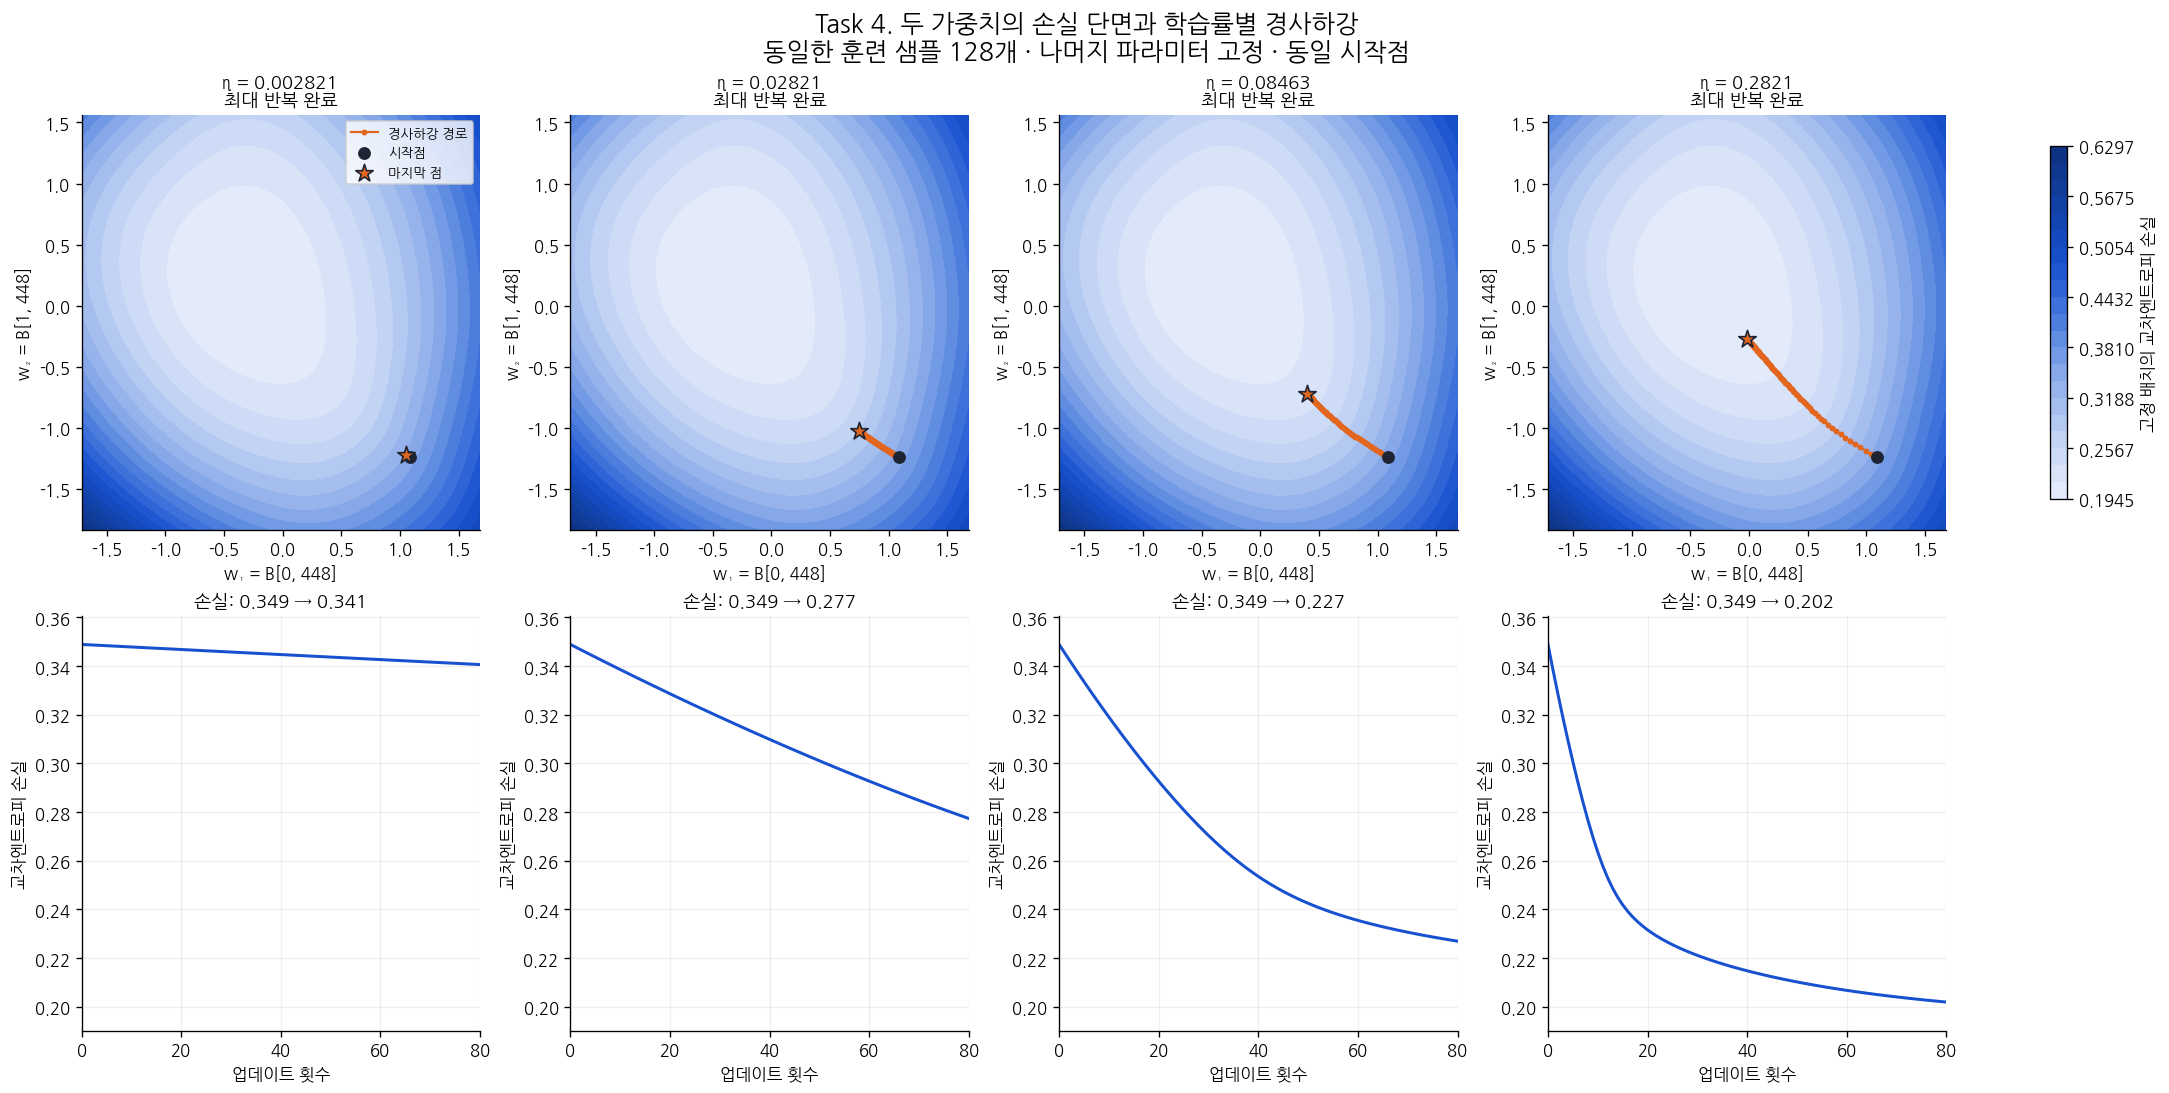

같은 시작점의 손실 0.349에서 두 가중치만 경사하강으로 갱신한 결과, 각 실행의 마지막 손실은 η=0.00282: 0.341; η=0.0282: 0.277; η=0.0846: 0.227; η=0.282: 0.202였으며 표시 범위를 이탈한 실행은 조기 중단하였다.


In [ ]:
fig, axes = plt.subplots(
    2, 4,
    figsize=(18, 9),
    constrained_layout=True
)

levels = np.linspace(
    float(L_grid.min()),
    float(L_grid.max()) + 1e-12,
    22
)

for k, run in enumerate(runs):
    ax = axes[0, k]
    path = run["path"]

    contour = ax.contourf(
        W1, W2, L_grid,
        levels=levels,
        cmap=LOSS_CMAP
    )

    ax.plot(
        path[:, 0],
        path[:, 1],
        "-o",
        color=COLORS[1],
        linewidth=1.3,
        markersize=2.5,
        label="경사하강 경로"
    )

    ax.scatter(
        path[0, 0], path[0, 1],
        color="#1E2433",
        marker="o",
        s=45,
        zorder=5,
        label="시작점"
    )

    # 끝점이 표시 범위 안에 있을 때만 그리기
    end_in_range = (
        lower[0] <= path[-1, 0] <= upper[0]
        and lower[1] <= path[-1, 1] <= upper[1]
    )

    if end_in_range:
        ax.scatter(
            path[-1, 0], path[-1, 1],
            color=COLORS[1],
            edgecolor="#1E2433",
            marker="*",
            s=120,
            zorder=6,
            label="마지막 점"
        )

    ax.set_xlim(float(lower[0]), float(upper[0]))
    ax.set_ylim(float(lower[1]), float(upper[1]))

    ax.set_xlabel(f"w₁ = B[0, {j}]")
    ax.set_ylabel(f"w₂ = B[1, {j}]")
    ax.set_title(
        f"η = {run['lr']:.4g}\n{run['status']}",
        fontsize=11
    )

    if k == 0:
        ax.legend(fontsize=8, loc="best")

    # 반복 횟수별 손실
    ax_loss = axes[1, k]

    ax_loss.plot(
        np.arange(len(run["losses"])),
        run["losses"],
        color=COLORS[0],
        linewidth=1.8
    )

    ax_loss.set_xlabel("업데이트 횟수")
    ax_loss.set_ylabel("교차엔트로피 손실")
    ax_loss.set_xlim(0, MAX_STEPS)
    ax_loss.grid(alpha=0.2)

    ax_loss.set_title(
        f"손실: {run['losses'][0]:.3f} → "
        f"{run['losses'][-1]:.3f}",
        fontsize=11
    )

# 손실 곡선도 같은 세로축 범위로 비교
all_curve_losses = np.concatenate(
    [run["losses"] for run in runs]
)

curve_min = float(all_curve_losses.min())
curve_max = float(all_curve_losses.max())
curve_pad = max((curve_max - curve_min) * 0.08, 0.01)

for ax in axes[1]:
    ax.set_ylim(
        max(0, curve_min - curve_pad),
        curve_max + curve_pad
    )

fig.colorbar(
    contour,
    ax=list(axes[0]),
    label="고정 배치의 교차엔트로피 손실",
    shrink=0.85
)

fig.suptitle(
    "Task 4. 두 가중치의 손실 단면과 학습률별 경사하강\n"
    "동일한 훈련 샘플 128개 · 나머지 파라미터 고정 · 동일 시작점",
    fontsize=15
)

loss_summary = "; ".join(
    f"η={r['lr']:.3g}: {r['losses'][-1]:.3f}"
    for r in runs
)

captions["task4"] = (
    f"같은 시작점의 손실 {runs[0]['losses'][0]:.3f}에서 "
    f"두 가중치만 경사하강으로 갱신한 결과, 각 실행의 마지막 손실은 "
    f"{loss_summary}였으며 표시 범위를 이탈한 실행은 조기 중단하였다."
)

figures["task4"] = fig

fig.savefig(
    SAVE_DIR / "task4_optimization.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()
print(captions["task4"])


In [ ]:
import textwrap

# 실제 실험 설정과 수치 저장
results = {
    "seed": SEED,
    "initialization": "ImageNet pretrained ResNet18",
    "input_size": [64, 64],
    "normalization_mean": list(MEAN),
    "normalization_std": list(STD),
    "augmentation": "none; deterministic resize and normalization",
    "backbone_finetune_epochs": BACKBONE_EPOCHS,
    "backbone_optimizer": "Adam",
    "backbone_learning_rate": 1e-4,
    "backbone_batch_size": train_loader.batch_size,
    "head_epochs": HEAD_EPOCHS,
    "head_optimizer": "Adam",
    "head_learning_rate": HEAD_LR,
    "head_batch_size": HEAD_BATCH_SIZE,
    "baseline_test_accuracy": baseline_acc,
    "two_neuron_test_accuracy": two_acc,
    "accuracy_drop_percentage_points": accuracy_drop,
    "baseline_test_loss": baseline_loss,
    "two_neuron_test_loss": two_loss,
    "slice_feature_index": j,
    "slice_selection_rule": "largest mean squared feature on fixed batch",
    "slice_batch_indices": batch_indices.tolist(),
    "slice_grid_size": GRID_SIZE,
    "slice_start": start.tolist(),
    "slice_reference_weights": w_reference.tolist(),
    "slice_lower_bounds": lower.tolist(),
    "slice_upper_bounds": upper.tolist(),
    "slice_optimizer": "gradient descent without momentum",
    "slice_max_steps": MAX_STEPS,
    "slice_learning_rates": learning_rates,
    "slice_stop_status": [r["status"] for r in runs],
    "captions": captions,
    "backbone_history": backbone_history,
    "baseline_history": baseline_history,
    "two_neuron_history": two_history,
}

with open(
    SAVE_DIR / "experiment_results.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

# 재확인할 수 있도록 원본 시각화 데이터 저장
arrays = {
    "Z": Z,
    "test_labels": labels_np,
    "baseline_predictions": baseline_pred.numpy(),
    "two_neuron_predictions": two_pred.numpy(),
    "W1": W1,
    "W2": W2,
    "loss_grid": L_grid
}

for k, run in enumerate(runs):
    arrays[f"path_{k}"] = run["path"]
    arrays[f"losses_{k}"] = run["losses"]

np.savez_compressed(
    SAVE_DIR / "visualization_data.npz",
    **arrays
)

# 설명 문장 저장
with open(
    SAVE_DIR / "figure_captions.txt",
    "w",
    encoding="utf-8"
) as f:
    for key in ["task1", "task2", "task3", "task4"]:
        f.write(f"{key.upper()}\n{captions[key]}\n\n")

# 이미 저장한 PNG를 이용해 항목당 한 페이지의 PDF 생성
png_names = {
    "task1": "task1_architecture.png",
    "task2": "task2_accuracy.png",
    "task3": "task3_representation.png",
    "task4": "task4_optimization.png",
}

pdf_path = SAVE_DIR / "Assignment1_figures.pdf"

with PdfPages(pdf_path) as pdf:
    for key in ["task1", "task2", "task3", "task4"]:
        page = plt.figure(figsize=(16.5, 11.7))

        image_ax = page.add_axes([0.04, 0.22, 0.92, 0.73])
        image_ax.imshow(
            plt.imread(SAVE_DIR / png_names[key])
        )
        image_ax.axis("off")

        wrapped_caption = textwrap.fill(
            captions[key],
            width=80
        )

        page.text(
            0.07, 0.16,
            wrapped_caption,
            ha="left",
            va="top",
            fontsize=12,
            linespacing=1.6
        )

        page.text(
            0.07, 0.045,
            "설정: ImageNet 사전학습 · CIFAR-10 64×64 · "
            "백본 미세조정 3 epochs · 고정 백본 위 두 헤드 각각 40 epochs",
            fontsize=9,
            color="#505A74"
        )

        pdf.savefig(page)
        plt.close(page)

print("저장된 파일:")
for path in sorted(SAVE_DIR.iterdir()):
    print(f"- {path.name} ({path.stat().st_size / 1024:.1f} KB)")

print("\n제출용 그림 PDF:", pdf_path)


저장된 파일:
- Assignment1_figures.pdf (1038.4 KB)
- baseline_head.pt (22.0 KB)
- experiment_results.json (12.2 KB)
- figure_captions.txt (0.7 KB)
- frozen_backbone.pt (43736.1 KB)
- resnet18_cifar10_checkpoint.pt (43758.4 KB)
- task1_architecture.png (96.2 KB)
- task2_accuracy.png (39.1 KB)
- task3_representation.png (527.5 KB)
- task4_optimization.png (278.0 KB)
- two_neuron_head.pt (6.6 KB)
- visualization_data.npz (153.4 KB)

제출용 그림 PDF: /content/drive/MyDrive/Assignment1_TwoNeurons/Assignment1_figures.pdf


In [ ]:
from google.colab import files

files.download(str(SAVE_DIR / "Assignment1_figures.pdf"))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>